You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.


<img src="ai_tools.jpg" align="center"/>

You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

### The Data

The Google Trends data is available as a CSV file `ai_tools_comparison.csv`.
The data contains the number of worldwide searches for chatGpt, Gemini, and Microsoft Copilot over the past 12 months as of September 2024. 
<!--- Link to query: https://trends.google.com/trends/explore?q=chatgpt,gemini,%2Fg%2F11tsqm45vd&hl=en-US -->

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


In [62]:
# Start coding here
# Use as many cells as you need

In [63]:
trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   week               54 non-null     object
 1   chatgpt            54 non-null     int64 
 2   gemini             54 non-null     int64 
 3   microsoft_copilot  54 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


In [64]:
trends['week'] = pd.to_datetime(trends['week'])

In [65]:
trends.set_index('week', inplace=True)

In [66]:
change=trends.pct_change().fillna(0).mul(100)

In [67]:
stds=change.std()

In [68]:
most_consistent_tool = stds[stds == stds.min()].index[0]

In [69]:
most_consistent_tool

'chatgpt'

In [70]:
trend_copy=trends.copy()

<AxesSubplot: title={'center': 'Intrest Levels'}, xlabel='week'>

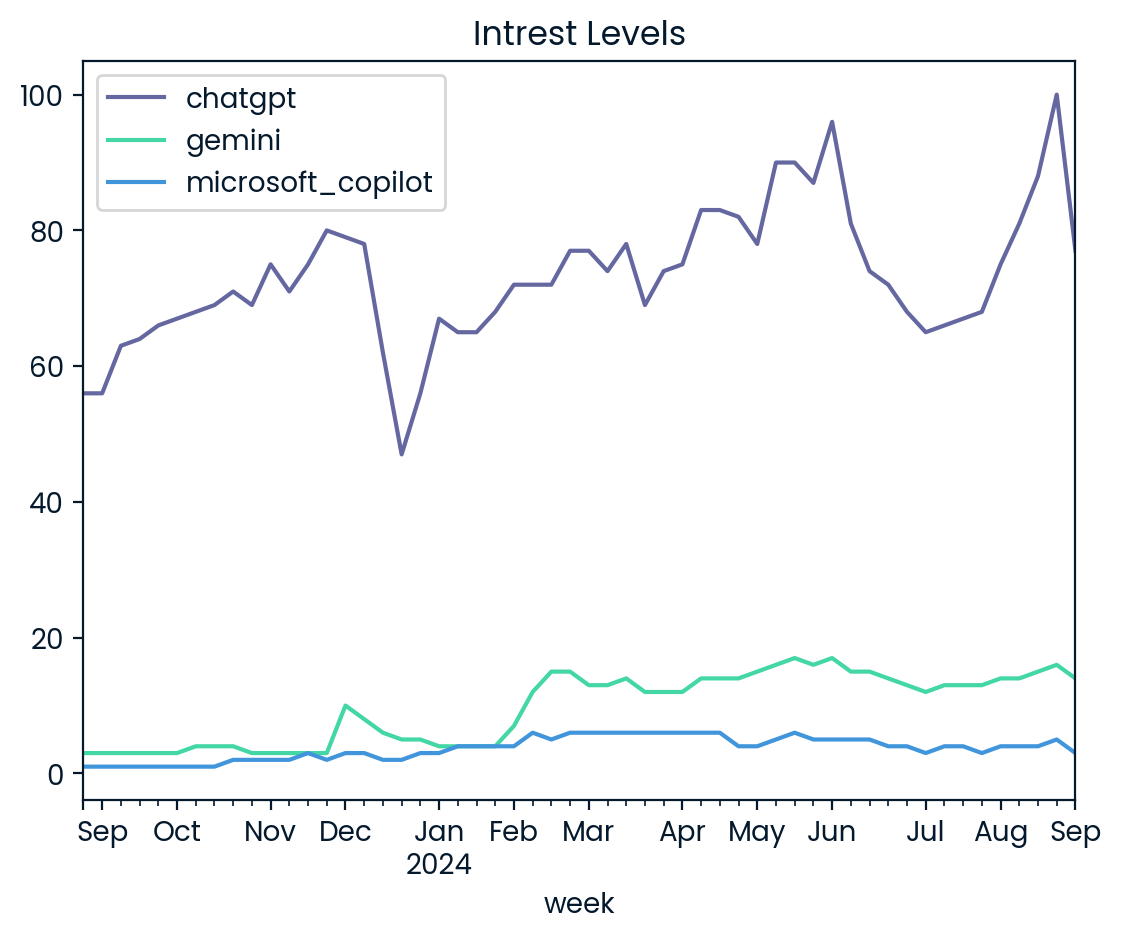

In [71]:
trend_copy.plot(title='Intrest Levels')


In [72]:
gpt_dip=trend_copy['chatgpt'].idxmin()

In [73]:
gpt_dip

Timestamp('2023-12-24 00:00:00')

In [74]:
gpt_dip=gpt_dip.strftime("%B %Y")

In [75]:
gpt_dip

'December 2023'

In [76]:
monthly_data = trends.resample('M').mean()

In [77]:
print(monthly_data.mean(axis=1).sort_values(ascending=False).index[0])

2024-05-31 00:00:00


In [78]:
best_month = monthly_data.mean(axis=1).idxmax().strftime('%B')


In [79]:
best_month

'May'